# Extractive Summarization Wikipedia
Pipeline penuh: preprocessing &#8594; 3 metode summarization &#8594; evaluasi ROUGE &#8594; analisis skor.

**Tiga objektif:**
1. **Summary quality** &#8212; memilih kalimat representatif (TF-IDF)
2. **Contextual understanding** &#8212; relasi antar-kalimat (TextRank) & semantik (BERT)
3. **Computational efficiency** &#8212; tanpa model berat; chunking untuk artikel panjang

**Urutan logis:** Setup &#8594; Preprocessing &#8594; Definisi fungsi &#8594; Generate &#8594; Evaluasi &#8594; Analisis.
Input: `data_final.csv`.

---
## 0. Setup

In [1]:
# ============================================================
# SETUP — Instalasi semua dependensi (jalankan sekali di awal)
# ============================================================
!pip install -q sentence-transformers rouge-score Sastrawi
# nltk, scikit-learn, networkx, pandas, matplotlib umumnya sudah ada di Kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 88.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('default')
pd.set_option('display.max_colwidth', 120)

In [2]:
files = [
    '/kaggle/input/datasets/nazhifberlian/nlp-wikipedia-summarization/data_artis.csv',
    '/kaggle/input/datasets/nazhifberlian/nlp-wikipedia-summarization/data_sejarah.csv',
    '/kaggle/input/datasets/nazhifberlian/nlp-wikipedia-summarization/data_arts.csv',
    '/kaggle/input/datasets/nazhifberlian/nlp-wikipedia-summarization/data_kuliner.csv',
    '/kaggle/input/datasets/nazhifberlian/nlp-wikipedia-summarization/data_sains.csv',
    '/kaggle/input/datasets/nazhifberlian/nlp-wikipedia-summarization/data_biografi.csv',
    '/kaggle/input/datasets/nazhifberlian/nlp-wikipedia-summarization/data_tech.csv',
]

dfs = []
row_counts = []

for f in files:
    if not os.path.exists(f):
        print(f'[!] File tidak ditemukan, dilewati: {f}')
        continue
    df = pd.read_csv(f, encoding='utf-8-sig')
    dfs.append(df)
    row_counts.append({'file': f, 'rows': len(df)})
    print(f'{f:20s} -> {len(df):5d} baris')

source_info = pd.DataFrame(row_counts)
source_info

/kaggle/input/datasets/nazhifberlian/nlp-wikipedia-summarization/data_artis.csv ->  1984 baris
/kaggle/input/datasets/nazhifberlian/nlp-wikipedia-summarization/data_sejarah.csv ->  2000 baris
/kaggle/input/datasets/nazhifberlian/nlp-wikipedia-summarization/data_arts.csv ->  2000 baris
/kaggle/input/datasets/nazhifberlian/nlp-wikipedia-summarization/data_kuliner.csv ->  1974 baris
/kaggle/input/datasets/nazhifberlian/nlp-wikipedia-summarization/data_sains.csv ->  1486 baris
/kaggle/input/datasets/nazhifberlian/nlp-wikipedia-summarization/data_biografi.csv ->  2000 baris
/kaggle/input/datasets/nazhifberlian/nlp-wikipedia-summarization/data_tech.csv ->  2000 baris


,file,rows
0,/kaggle/input/datasets/nazhifberlian/nlp-wikipedia-summarization/data_artis.csv,1984
1,/kaggle/input/datasets/nazhifberlian/nlp-wikipedia-summarization/data_sejarah.csv,2000
2,/kaggle/input/datasets/nazhifberlian/nlp-wikipedia-summarization/data_arts.csv,2000
3,/kaggle/input/datasets/nazhifberlian/nlp-wikipedia-summarization/data_kuliner.csv,1974
4,/kaggle/input/datasets/nazhifberlian/nlp-wikipedia-summarization/data_sains.csv,1486
5,/kaggle/input/datasets/nazhifberlian/nlp-wikipedia-summarization/data_biografi.csv,2000
6,/kaggle/input/datasets/nazhifberlian/nlp-wikipedia-summarization/data_tech.csv,2000


/tmp/ipykernel_58/3750332309.py:7: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


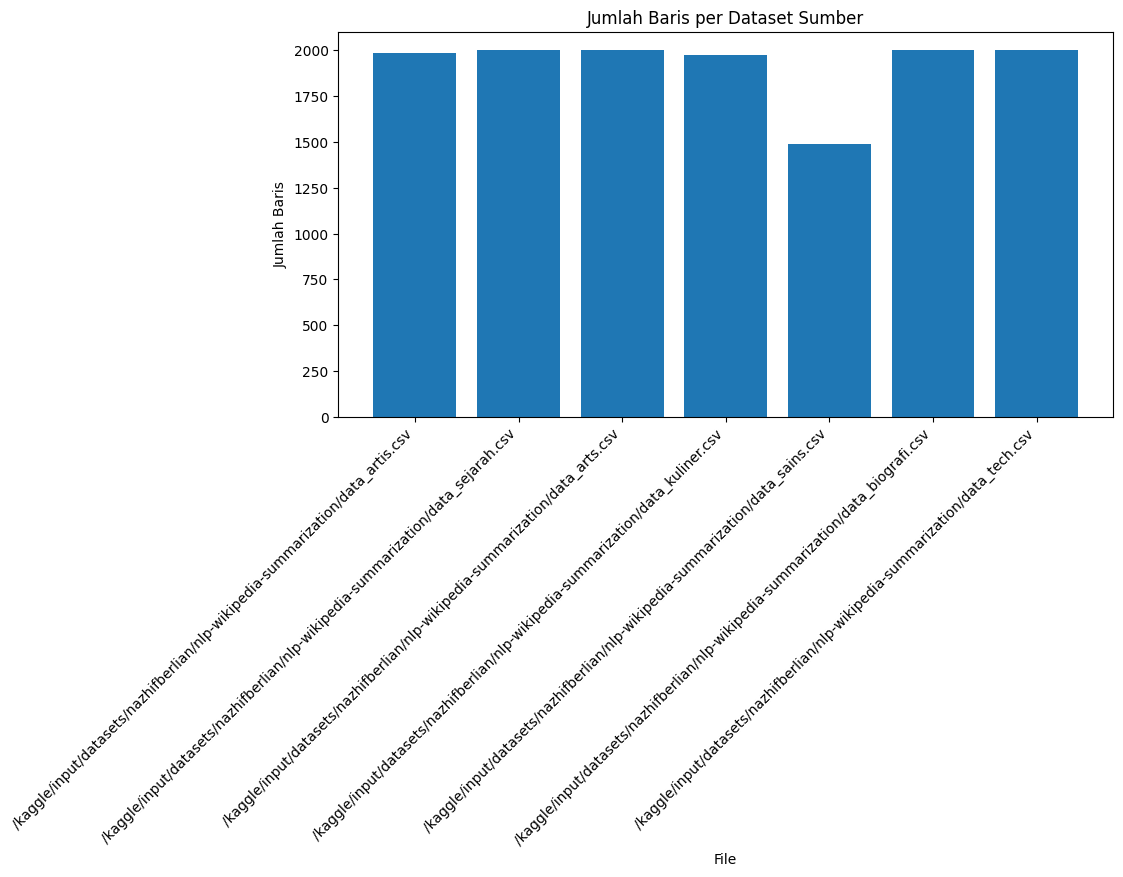

In [3]:
plt.figure(figsize=(10, 5))
plt.bar(source_info['file'], source_info['rows'])
plt.xticks(rotation=45, ha='right')
plt.title('Jumlah Baris per Dataset Sumber')
plt.xlabel('File')
plt.ylabel('Jumlah Baris')
plt.tight_layout()
plt.show()

In [4]:
merged = pd.concat(dfs, ignore_index=True)
merged.insert(0, 'global_id', [f'doc_{i:05d}' for i in range(len(merged))])

print(f'Total setelah merge: {len(merged)} baris')
print(f'Jumlah kolom       : {len(merged.columns)}')
merged.head()

Total setelah merge: 13444 baris
Jumlah kolom       : 8


,global_id,id,title,category,article_text,body_word_count,lead_paragraph,lead_word_count
0,doc_00000,artist_0000,Daftar artis cilik Indonesia,artis,Keberadaan penyanyi cilik di Indonesia telah eksis sejak era 60-an. Pada saat itu sudah ada beberapa penyanyi anak-a...,502,Artis cilik adalah sebutan bagi selebritis yang merintis karier di usia kanak-kanak (14 tahun ke bawah). Artis cilik...,94
1,doc_00001,artist_0001,A. Sarosa,artis,"Ali Sarosa lahir pada tanggal 20 Februari 1918 di Banyumas, Jawa Tengah. Beliau menyelesaikan pendidikannya di MULO ...",178,Ali Sarosa lebih dikenal dengan nama panggung A. Sarosa (20 Februari 1918 - 19 November 1975) adalah seorang aktor f...,61
2,doc_00002,artist_0002,Onadio Leonardo,artis,Onadio menjalin hubungan asmara berbeda agama dengan Beby Prisillia Gustiansyah—yang kini dikenal sebagai Beby Leona...,120,"Leonardo Arya, dikenal sebagai Onadio Leonardo (lahir 4 Januari 1990) adalah musisi, pemeran, presenter, dan penyiar...",51
3,doc_00003,artist_0003,Shabrina Leonita,artis,"Shabrina terlahir dengan nama Shabrina Leonita pada 23 Juli 2000 di Belitung Timur, Bangka Belitung. Ia adalah anak ...",343,Shabrina Leonita atau lebih dikenal dengan Shabrina Leanor (lahir 23 Juli 2000) adalah seorang penyanyi berkebangsaa...,77
4,doc_00004,artist_0004,Aktor pemeran Soekarno,artis,Karakter Bung Karno yang begitu kuat dan karismatik membuatnya sangat menarik untuk diangkat ke dalam sebuah karya s...,779,"Di kancah perfilman, hiburan televisi, dan panggung teater Indonesia, ada beberapa aktor pemeran Bung Karno. Semua a...",50


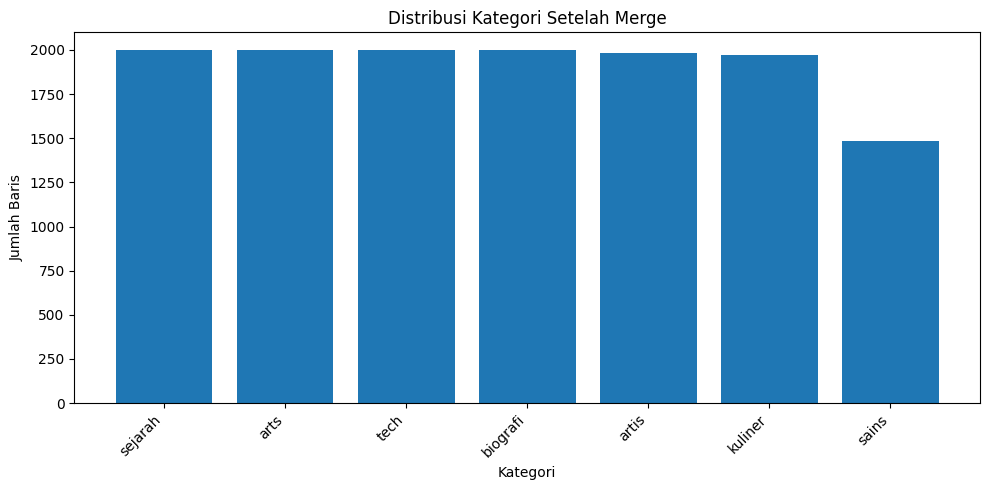

,category,rows
0,sejarah,2000
1,arts,2000
2,tech,2000
3,biografi,2000
4,artis,1984
5,kuliner,1974
6,sains,1486


In [5]:
category_counts = merged['category'].value_counts().reset_index()
category_counts.columns = ['category', 'rows']

plt.figure(figsize=(10, 5))
plt.bar(category_counts['category'], category_counts['rows'])
plt.xticks(rotation=45, ha='right')
plt.title('Distribusi Kategori Setelah Merge')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Baris')
plt.tight_layout()
plt.show()

category_counts

In [6]:
merged['_title_norm'] = merged['title'].astype(str).str.lower().str.strip()

duplicate_titles = merged[merged.duplicated('_title_norm', keep=False)]
dup_summary = pd.DataFrame({
    'keterangan': ['Jumlah judul unik duplikat', 'Jumlah baris yang terlibat duplikat'],
    'nilai': [duplicate_titles['_title_norm'].nunique(), len(duplicate_titles)]
})

dup_summary

,keterangan,nilai
0,Jumlah judul unik duplikat,672
1,Jumlah baris yang terlibat duplikat,1362


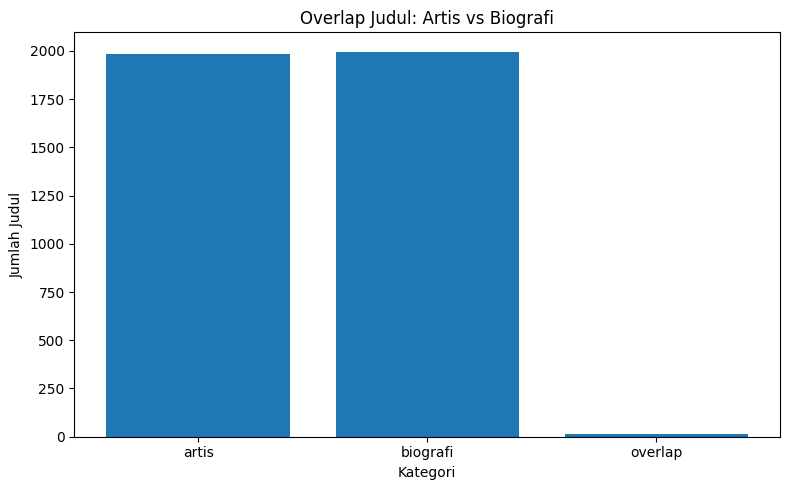

Overlap judul artis <-> biografi: 13

Contoh judul overlap:
- ahmad dhani
- aktor pemeran soekarno
- arya wedakarna
- basofi sudirman
- imam budi hartono
- inayah wulandari
- lucky hakim
- marissa haque
- mayangsari
- nurul arifin


In [7]:
artis = set(merged.loc[merged['category'] == 'artis', '_title_norm'])
biografi = set(merged.loc[merged['category'] == 'biografi', '_title_norm'])
overlap = sorted(artis & biografi)

overlap_info = pd.DataFrame({
    'kategori': ['artis', 'biografi', 'overlap'],
    'jumlah_judul': [len(artis), len(biografi), len(overlap)]
})

plt.figure(figsize=(8, 5))
plt.bar(overlap_info['kategori'], overlap_info['jumlah_judul'])
plt.title('Overlap Judul: Artis vs Biografi')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Judul')
plt.tight_layout()
plt.show()

print(f'Overlap judul artis <-> biografi: {len(overlap)}')
print('\nContoh judul overlap:')
for t in overlap[:10]:
    print('-', t)

In [8]:
to_drop = merged[
    (merged['category'] == 'artis') &
    (merged['_title_norm'].isin(overlap))
].index

merged_clean = merged.drop(index=to_drop)
merged_clean = merged_clean.drop_duplicates('_title_norm', keep='first')
merged_clean = merged_clean.drop(columns='_title_norm')

print(f'Baris sebelum cleaning : {len(merged)}')
print(f'Baris dibuang overlap   : {len(to_drop)}')
print(f'Baris setelah cleaning  : {len(merged_clean)}')

Baris sebelum cleaning : 13444
Baris dibuang overlap   : 13
Baris setelah cleaning  : 12754


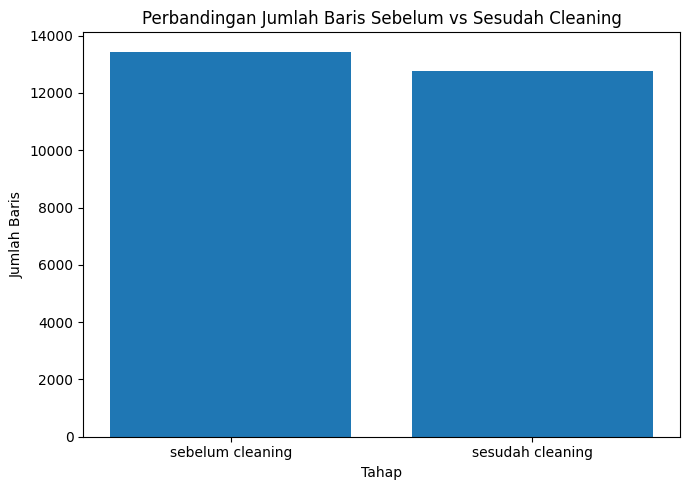

,tahap,jumlah_baris
0,sebelum cleaning,13444
1,sesudah cleaning,12754


In [9]:
summary = pd.DataFrame({
    'tahap': ['sebelum cleaning', 'sesudah cleaning'],
    'jumlah_baris': [len(merged), len(merged_clean)]
})

plt.figure(figsize=(7, 5))
plt.bar(summary['tahap'], summary['jumlah_baris'])
plt.title('Perbandingan Jumlah Baris Sebelum vs Sesudah Cleaning')
plt.xlabel('Tahap')
plt.ylabel('Jumlah Baris')
plt.tight_layout()
plt.show()

summary

In [10]:
merged_clean.to_csv('data_final.csv', index=False, encoding='utf-8-sig')
print('Tersimpan: data_final.csv')

Tersimpan: data_final.csv


---
## 1. Load & Preprocessing

### 1a. Load dataset

In [2]:
import re
import numpy as np
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/nazhifberlian/nlp-wikipedia-summarization/data_final.csv', encoding='utf-8-sig')

print(f'Dataset dimuat: {len(df)} baris, {len(df.columns)} kolom')
print(f'Kolom: {list(df.columns)}')
print(f'\nDistribusi kategori:')
print(df['category'].value_counts().to_string())

Dataset dimuat: 12754 baris, 8 kolom
Kolom: ['global_id', 'id', 'title', 'category', 'article_text', 'body_word_count', 'lead_paragraph', 'lead_word_count']

Distribusi kategori:
category
sejarah     1986
arts        1975
artis       1971
kuliner     1958
tech        1728
biografi    1701
sains       1435


### 1b. Pembersihan teks

In [3]:
def clean_text(text):
    text = str(text)
    text = re.sub(r'\[\d+\]', '', text)                      # hapus referensi [1], [2]
    text = re.sub(r'={2,}.*?={2,}', '', text)                # hapus == heading ==
    text = re.sub(r'http\S+|www\.\S+', '', text)             # hapus URL
    text = re.sub(r'\{\{.*?\}\}', '', text, flags=re.DOTALL) # hapus {{template}}
    text = text.replace('\u201c', '"').replace('\u201d', '"')
    text = text.replace('\u2018', "'").replace('\u2019', "'")
    text = text.replace('\u2013', '-').replace('\u2014', '-')
    text = re.sub(r'\s+', ' ', text)                         # rapikan spasi/newline
    text = text.lower()    # dan hapus semua karakter selain huruf, angka, spasi, koma, titik
    text = re.sub(r"[^a-z0-9\s,.]", "", text)
    return text.strip()

df['clean_text'] = df['article_text'].apply(clean_text)
print('Preprocessing selesai.')
print(f'Contoh: {df["clean_text"].iloc[0][:200]}')

Preprocessing selesai.
Contoh: keberadaan penyanyi cilik di indonesia telah eksis sejak era 60an. pada saat itu sudah ada beberapa penyanyi anakanak seperti fenty effendy, anna mathovani, atau nenny triana. namun yang bisa dibilang


### 1c. Re-filter artikel pendek

In [4]:
df['body_word_count'] = df['clean_text'].str.split().str.len()

MIN_WORDS = 100  # ambang minimal kata untuk artikel yang layak diringkas

before = len(df)
df = df[df['body_word_count'] >= MIN_WORDS].reset_index(drop=True)
print(f'Sebelum filter: {before} baris')
print(f'Sesudah filter: {len(df)} baris')
print(f'\nStatistik panjang artikel:')
print(df['body_word_count'].describe().round(0).to_string())

Sebelum filter: 12754 baris
Sesudah filter: 12644 baris

Statistik panjang artikel:
count    12644.0
mean       452.0
std        484.0
min        100.0
25%        182.0
50%        302.0
75%        538.0
max      11947.0


---
## 2. Definisi Fungsi Summarization

### 2a. Pemecahan kalimat

In [5]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

def split_sentences(text):
    # NLTK menangani singkatan & tanda baca lebih baik daripada split manual
    sentences = sent_tokenize(text)
    return [s.strip() for s in sentences if len(s.split()) >= 4]

contoh = split_sentences(df['clean_text'].iloc[0])
print(f'Jumlah kalimat di artikel pertama: {len(contoh)}')
print(f'Kalimat pertama: {contoh[0]}')

Jumlah kalimat di artikel pertama: 22
Kalimat pertama: keberadaan penyanyi cilik di indonesia telah eksis sejak era 60an.


### 2b. Metode 1 — TF-IDF Sentence Ranking

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

STOPWORDS_ID = set("""
yang di ke dari dan atau pada untuk dengan adalah ini itu dalam tidak akan
sebagai juga oleh karena sudah dapat telah agar bisa saat para suatu setelah
hingga maupun sebuah merupakan namun yaitu serta secara hanya masih lebih tersebut
""".split())

def summarize_tfidf(text, n_sentences=3):
    # OBJEKTIF: summary quality + computational efficiency.
    sentences = split_sentences(text)
    if len(sentences) <= n_sentences:
        return ' '.join(sentences)
    vectorizer = TfidfVectorizer(stop_words=list(STOPWORDS_ID), lowercase=True)
    tfidf_matrix = vectorizer.fit_transform(sentences)
    scores = tfidf_matrix.sum(axis=1).A1
    top_idx = sorted(scores.argsort()[-n_sentences:])
    return ' '.join(sentences[i] for i in top_idx)

print('=== Contoh ringkasan TF-IDF ===')
print(summarize_tfidf(df['clean_text'].iloc[0], 3))

=== Contoh ringkasan TF-IDF ===
sekitar tahun 20042006, televisi anak spacetoon menayangkan kembali acara bando yang dulu sempat ditayangkan di antv, tetapi rupanya pasar musik kala itu benarbenar sudah tak berpihak pada lagu anakanak, sehingga penyanyipenyanyi yang video klipnya sering diputar di acara tersebut, tidak segemilang penyanyi cilik era sebelumnya. era penyanyi cilik belakangan muncul kembali di awal dekade 2010an, kebanyakan dalam bentuk grup vokal mengikuti tren pasar boy band dan girl group, meskipun beberapa dari mereka kerap kali mempopulerkan lagulagu yang lebih cocok untuk usia 13 tahun ke atas bertema cinta monyet. meski tak ada data yang pasti, tetapi artis cilik yang diyakini menjadi pelopor komika cilik di indonesia adalah fatih unru karena tercatat pernah melakukan aksi lawak tunggal di beberapa program televisi, sementara itu karin putri lestari menjadi peserta ajang pencarian komika pertama di indonesia yang masih berusia anakanak, melalui ajang stand up comed

### 2c. Metode 2 — TextRank

In [7]:
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx

def summarize_textrank(text, n_sentences=3):
    # OBJEKTIF: contextual understanding (relasi antar-kalimat via PageRank).
    sentences = split_sentences(text)
    if len(sentences) <= n_sentences:
        return ' '.join(sentences)
    vectorizer = TfidfVectorizer(stop_words=list(STOPWORDS_ID), lowercase=True)
    tfidf_matrix = vectorizer.fit_transform(sentences)
    sim_matrix = cosine_similarity(tfidf_matrix)
    np.fill_diagonal(sim_matrix, 0)
    graph = nx.from_numpy_array(sim_matrix)
    scores = nx.pagerank(graph, max_iter=100)
    ranked = sorted(scores, key=scores.get, reverse=True)
    top_idx = sorted(ranked[:n_sentences])
    return ' '.join(sentences[i] for i in top_idx)

print('=== Contoh ringkasan TextRank ===')
print(summarize_textrank(df['clean_text'].iloc[0], 3))

=== Contoh ringkasan TextRank ===
keberadaan penyanyi cilik di indonesia telah eksis sejak era 60an. beberapa aktor dan mantan aktor cilik di indonesia antara lain komedian cilik di indonesia terhitung belum terlalu banyak. meski tak ada data yang pasti, tetapi artis cilik yang diyakini menjadi pelopor komika cilik di indonesia adalah fatih unru karena tercatat pernah melakukan aksi lawak tunggal di beberapa program televisi, sementara itu karin putri lestari menjadi peserta ajang pencarian komika pertama di indonesia yang masih berusia anakanak, melalui ajang stand up comedy academy musim ketiga pada tahun 2017. beberapa presenter dan mantan presenter cilik di indonesia antara lain


### 2d. Chunking & helper adaptif

In [8]:
# CHUNKING: artikel panjang membuat matriks similarity membengkak (O(n^2)).
# Pecah jadi chunk berbasis kalimat agar efisien -> menjaga computational efficiency.
MAX_SENTENCES_PER_CHUNK = 30

def chunk_sentences(sentences, max_per_chunk=MAX_SENTENCES_PER_CHUNK):
    return [sentences[i:i + max_per_chunk]
            for i in range(0, len(sentences), max_per_chunk)]

def summarize_with_chunking(text, method='textrank', n_sentences=3):
    # Artikel panjang: ringkas per chunk -> gabung -> ringkas final (hierarchical).
    sentences = split_sentences(text)
    summarizer = summarize_textrank if method == 'textrank' else summarize_tfidf
    if len(sentences) <= MAX_SENTENCES_PER_CHUNK:
        return summarizer(text, n_sentences)
    chunks = chunk_sentences(sentences)
    chunk_summaries = [summarizer(' '.join(c), n_sentences=2) for c in chunks]
    return summarizer(' '.join(chunk_summaries), n_sentences)

# Panjang ringkasan adaptif mengikuti panjang artikel
def adaptive_n(text):
    n = len(text.split())
    if n < 500:  return 2
    if n < 1500: return 3
    return 4

idx_panjang = df['body_word_count'].idxmax()
print(f'Artikel terpanjang: {df["body_word_count"].iloc[idx_panjang]} kata')
print('Ringkasan (dengan chunking):')
print(summarize_with_chunking(df['clean_text'].iloc[idx_panjang], 'textrank')[:300])

Artikel terpanjang: 11947 kata
Ringkasan (dengan chunking):
sebuah gerbong kereta terguling di jalur kereta api padalarangcianjur yang mengakibatkan korban jiwa sekitar 80 korban jiwa. tidak ada korban jiwa dari peristiwa ini, tetapi perjalanan kereta api di jalur ini terganggu selama 14 jam dan mengakibatkan kerusakan pada wesel jalur 3 stasiun ini. peristi


### 2e. Metode 3 — BERT (setup model)
Embedding semantik; tetap extractive (pilih kalimat asli, tanpa halusinasi).

In [9]:
# ============================================================
# BERT Extractive Summarization — metode ketiga
# ============================================================
# BERT memakai EMBEDDING SEMANTIK (menangkap makna, bukan sekadar kata sama).
# Tetap extractive: memilih kalimat asli, tanpa halusinasi.
from sentence_transformers import SentenceTransformer
import torch

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

bert_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2', device=DEVICE)
print(f'Model BERT dimuat: {bert_model.get_sentence_embedding_dimension()} dimensi')

Device: cuda


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model BERT dimuat: 384 dimensi


/tmp/ipykernel_22/2195591896.py:13: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f'Model BERT dimuat: {bert_model.get_sentence_embedding_dimension()} dimensi')


### 2f. Metode 3 — BERT (fungsi)

In [10]:
def summarize_bert(text, n_sentences=3):
    # Pilih kalimat yang embeddingnya paling mirip tema dokumen (rata-rata embedding).
    sentences = split_sentences(text)
    if len(sentences) <= n_sentences:
        return ' '.join(sentences)
    embeddings = bert_model.encode(sentences, show_progress_bar=False)
    doc_embedding = embeddings.mean(axis=0, keepdims=True)
    scores = cosine_similarity(embeddings, doc_embedding).flatten()
    top_idx = sorted(scores.argsort()[-n_sentences:])
    return ' '.join(sentences[i] for i in top_idx)

def summarize_with_chunking_bert(text, n_sentences=3):
    sentences = split_sentences(text)
    if len(sentences) <= MAX_SENTENCES_PER_CHUNK:
        return summarize_bert(text, n_sentences)
    chunks = chunk_sentences(sentences)
    chunk_summaries = [summarize_bert(' '.join(c), n_sentences=2) for c in chunks]
    return summarize_bert(' '.join(chunk_summaries), n_sentences)

print('Fungsi BERT siap.')

Fungsi BERT siap.


---
## 3. Generate Ringkasan (Ketiga Metode)
TextRank dihitung **sekali** di sini &#8212; tidak ada duplikasi. TF-IDF & TextRank dulu (cepat), lalu BERT.

In [11]:
# ============================================================
# Generate ringkasan ketiga metode untuk seluruh dataset
# ============================================================
# TextRank dihitung SEKALI di sini (tidak ada duplikasi).
# Urutan: TF-IDF & TextRank dulu (cepat), lalu BERT (lebih lambat).
from tqdm import tqdm
tqdm.pandas()

print('1/3 TF-IDF...')
df['summary_tfidf'] = df['clean_text'].progress_apply(
    lambda x: summarize_with_chunking(x, method='tfidf', n_sentences=adaptive_n(x)))

print('2/3 TextRank...')
df['summary_textrank'] = df['clean_text'].progress_apply(
    lambda x: summarize_with_chunking(x, method='textrank', n_sentences=adaptive_n(x)))

print('3/3 BERT...')
df['summary_bert'] = df['clean_text'].progress_apply(
    lambda x: summarize_with_chunking_bert(x, n_sentences=adaptive_n(x)))

print('\nKetiga ringkasan selesai.')
print(f'Kolom tersedia: summary_tfidf, summary_textrank, summary_bert')

1/3 TF-IDF...


100%|██████████| 12644/12644 [00:42<00:00, 299.72it/s]


2/3 TextRank...


100%|██████████| 12644/12644 [01:22<00:00, 153.21it/s]


3/3 BERT...


100%|██████████| 12644/12644 [08:09<00:00, 25.83it/s]


Ketiga ringkasan selesai.
Kolom tersedia: summary_tfidf, summary_textrank, summary_bert


### 3b. Perbandingan kualitatif ketiga metode

In [12]:
# Perbandingan kualitatif ketiga metode pada artikel yang sama
idx = 0
print(f'JUDUL: {df["title"].iloc[idx]}\n')
print('--- GROUND TRUTH (lead) ---')
print(df['lead_paragraph'].iloc[idx][:250], '\n')
print('--- TF-IDF ---')
print(df['summary_tfidf'].iloc[idx][:250], '\n')
print('--- TextRank ---')
print(df['summary_textrank'].iloc[idx][:250], '\n')
print('--- BERT ---')
print(df['summary_bert'].iloc[idx][:250])

JUDUL: Daftar artis cilik Indonesia

--- GROUND TRUTH (lead) ---
Artis cilik adalah sebutan bagi selebritis yang merintis karier di usia kanak-kanak (14 tahun ke bawah). Artis cilik bisa berupa aktor, aktris, penyanyi, maupun multiprofesi. Selebritis dewasa yang semasa kecilnya sudah menjadi artis sering kali diid 

--- TF-IDF ---
sekitar tahun 20042006, televisi anak spacetoon menayangkan kembali acara bando yang dulu sempat ditayangkan di antv, tetapi rupanya pasar musik kala itu benarbenar sudah tak berpihak pada lagu anakanak, sehingga penyanyipenyanyi yang video klipnya s 

--- TextRank ---
keberadaan penyanyi cilik di indonesia telah eksis sejak era 60an. beberapa aktor dan mantan aktor cilik di indonesia antara lain komedian cilik di indonesia terhitung belum terlalu banyak. meski tak ada data yang pasti, tetapi artis cilik yang diyak 

--- BERT ---
namun ada juga beberapa penyanyi cilik yang memang sudah punya bakat alami dan mampu menyanyi dengan teknik vokal khas penyanyi pro

### 3c. Simpan hasil

In [13]:
# Simpan hasil ketiga metode
output_cols = ['global_id', 'title', 'category',
               'summary_tfidf', 'summary_textrank', 'summary_bert',
               'lead_paragraph', 'body_word_count']
hasil = df[[c for c in output_cols if c in df.columns]]
hasil.to_csv('hasil_summary.csv', index=False, encoding='utf-8-sig')
print(f'Tersimpan: hasil_summary.csv ({len(hasil)} baris)')

Tersimpan: hasil_summary.csv (12644 baris)


---
## 4. Evaluasi ROUGE

### 4a. Skor ketiga metode

In [14]:
# ============================================================
# Evaluasi ROUGE — ketiga metode
# ============================================================
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)

def rouge_avg(pred_series, ref_series):
    # Rata-rata F-measure ROUGE-1/2/L atas dua kolom teks.
    r1, r2, rl = [], [], []
    for pred, ref in zip(pred_series, ref_series):
        s = scorer.score(str(ref), str(pred))
        r1.append(s['rouge1'].fmeasure)
        r2.append(s['rouge2'].fmeasure)
        rl.append(s['rougeL'].fmeasure)
    return np.mean(r1), np.mean(r2), np.mean(rl)

methods = [
    ('TF-IDF',   'summary_tfidf'),
    ('TextRank', 'summary_textrank'),
    ('BERT',     'summary_bert'),
]

print(f'{"Metode":<10} | {"ROUGE-1":>8} | {"ROUGE-2":>8} | {"ROUGE-L":>8}')
print('-' * 48)
hasil_rouge = {}
for name, col in methods:
    r1, r2, rl = rouge_avg(df[col], df['lead_paragraph'])
    hasil_rouge[name] = (r1, r2, rl)
    print(f'{name:<10} | {r1:>8.4f} | {r2:>8.4f} | {rl:>8.4f}')

Metode     |  ROUGE-1 |  ROUGE-2 |  ROUGE-L
------------------------------------------------
TF-IDF     |   0.2069 |   0.0460 |   0.1198
TextRank   |   0.1984 |   0.0482 |   0.1245
BERT       |   0.1892 |   0.0432 |   0.1186


### 4b. Perbandingan per kategori (TF-IDF vs TextRank)

In [15]:
# ============================================================
# Perbandingan TF-IDF vs TextRank per kategori
# ============================================================
rows = []
for kategori in sorted(df['category'].unique()):
    sub = df[df['category'] == kategori]
    row = {'kategori': kategori, 'jumlah': len(sub)}
    for name, col in [('TF-IDF', 'summary_tfidf'), ('TextRank', 'summary_textrank')]:
        scores = [scorer.score(str(ref), str(pred))['rougeL'].fmeasure
                  for pred, ref in zip(sub[col], sub['lead_paragraph'])]
        row[f'{name}_rougeL'] = np.mean(scores)
    row['selisih'] = row['TextRank_rougeL'] - row['TF-IDF_rougeL']
    rows.append(row)

tabel = pd.DataFrame(rows).sort_values('selisih', ascending=False)
print('Perbandingan ROUGE-L per kategori (TextRank vs TF-IDF):')
print('=' * 65)
print(tabel.round(4).to_string(index=False))
print('\nSelisih positif = TextRank unggul; negatif = TF-IDF unggul')

Perbandingan ROUGE-L per kategori (TextRank vs TF-IDF):
kategori  jumlah  TF-IDF_rougeL  TextRank_rougeL  selisih
    tech    1716         0.1209           0.1301   0.0092
 kuliner    1944         0.1214           0.1287   0.0073
 sejarah    1976         0.1275           0.1348   0.0073
   sains    1417         0.1160           0.1218   0.0057
biografi    1679         0.1121           0.1170   0.0049
   artis    1947         0.1165           0.1180   0.0015
    arts    1965         0.1219           0.1199  -0.0020

Selisih positif = TextRank unggul; negatif = TF-IDF unggul


### 4c. Visualisasi

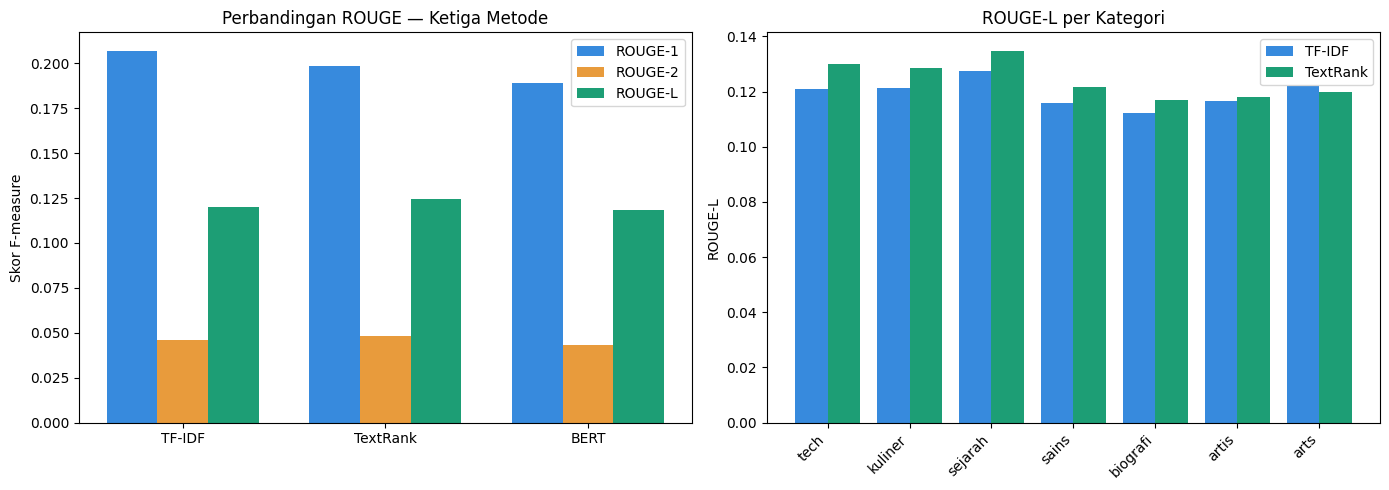

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

metode_nama = list(hasil_rouge.keys())
x = np.arange(len(metode_nama))
w = 0.25
ax[0].bar(x - w, [hasil_rouge[m][0] for m in metode_nama], w, label='ROUGE-1', color='#378ADD')
ax[0].bar(x,     [hasil_rouge[m][1] for m in metode_nama], w, label='ROUGE-2', color='#E89B3C')
ax[0].bar(x + w, [hasil_rouge[m][2] for m in metode_nama], w, label='ROUGE-L', color='#1D9E75')
ax[0].set_xticks(x); ax[0].set_xticklabels(metode_nama)
ax[0].set_title('Perbandingan ROUGE — Ketiga Metode')
ax[0].set_ylabel('Skor F-measure'); ax[0].legend()

kat = tabel['kategori'].tolist()
xk = np.arange(len(kat))
ax[1].bar(xk - 0.2, tabel['TF-IDF_rougeL'], 0.4, label='TF-IDF', color='#378ADD')
ax[1].bar(xk + 0.2, tabel['TextRank_rougeL'], 0.4, label='TextRank', color='#1D9E75')
ax[1].set_xticks(xk); ax[1].set_xticklabels(kat, rotation=45, ha='right')
ax[1].set_title('ROUGE-L per Kategori')
ax[1].set_ylabel('ROUGE-L'); ax[1].legend()

plt.tight_layout(); plt.show()

---
## 5. Analisis Skor ROUGE Rendah

### 5a. Stemming — uji efek variasi imbuhan

In [17]:
# ============================================================
# Analisis 1: ROUGE dengan vs tanpa Stemming
# ============================================================
# Menguji apakah skor rendah disebabkan variasi imbuhan ("dimasak" vs "memasak").
# Jika skor NAIK setelah stemming -> terbukti masalah ada di bentuk kata,
# bukan di kualitas ringkasan.
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

stemmer = StemmerFactory().create_stemmer()

tqdm.pandas(desc='Stemming summary')
df['_pred_stem'] = df['summary_textrank'].progress_apply(lambda x: stemmer.stem(str(x)))
tqdm.pandas(desc='Stemming lead')
df['_ref_stem'] = df['lead_paragraph'].progress_apply(lambda x: stemmer.stem(str(x)))
print('Stemming selesai.')

Stemming lead: 100%|██████████| 12644/12644 [1:25:39<00:00,  2.46it/s]

Stemming selesai.


### 5b. Bandingkan ROUGE dengan vs tanpa stemming

In [18]:
tanpa  = rouge_avg(df['summary_textrank'], df['lead_paragraph'])
dengan = rouge_avg(df['_pred_stem'], df['_ref_stem'])

print(f'{"":15} | {"ROUGE-1":>9} | {"ROUGE-2":>9} | {"ROUGE-L":>9}')
print('-' * 52)
print(f'{"Tanpa stemming":15} | {tanpa[0]:>9.4f} | {tanpa[1]:>9.4f} | {tanpa[2]:>9.4f}')
print(f'{"Dengan stemming":15} | {dengan[0]:>9.4f} | {dengan[1]:>9.4f} | {dengan[2]:>9.4f}')
print('-' * 52)
naik_r1 = (dengan[0] - tanpa[0]) / tanpa[0] * 100
naik_rl = (dengan[2] - tanpa[2]) / tanpa[2] * 100
print(f'{"Kenaikan":15} | {naik_r1:>+8.1f}% | {"":>9} | {naik_rl:>+7.1f}%')
print(f'\nKenaikan ROUGE-1 {naik_r1:.1f}% membuktikan sebagian skor hilang')
print(f'hanya karena perbedaan imbuhan, bukan ringkasan tidak relevan.')

                |   ROUGE-1 |   ROUGE-2 |   ROUGE-L
----------------------------------------------------
Tanpa stemming  |    0.1984 |    0.0482 |    0.1245
Dengan stemming |    0.2125 |    0.0503 |    0.1300
----------------------------------------------------
Kenaikan        |     +7.1% |           |    +4.4%

Kenaikan ROUGE-1 7.1% membuktikan sebagian skor hilang
hanya karena perbedaan imbuhan, bukan ringkasan tidak relevan.


### 5c. Oracle ceiling — fungsi

In [19]:
# ============================================================
# Analisis 2: Oracle Ceiling — batas atas teoretis
# ============================================================
# Oracle "mengintip" ground truth untuk memilih kombinasi kalimat terbaik.
# Tidak ada metode nyata yang bisa melampauinya. Jika oracle juga terbatas,
# berarti skor maksimum dataset ini memang rendah -> bukan salah metode.
def oracle_summary(text, reference, n_sentences=3):
    sentences = split_sentences(text)
    if len(sentences) <= n_sentences:
        return ' '.join(sentences)
    selected, remaining = [], list(range(len(sentences)))
    for _ in range(n_sentences):
        best_idx, best_score = None, -1
        for i in remaining:
            cand = ' '.join(sentences[j] for j in sorted(selected + [i]))
            sc = scorer.score(str(reference), cand)['rougeL'].fmeasure
            if sc > best_score:
                best_score, best_idx = sc, i
        if best_idx is None:
            break
        selected.append(best_idx)
        remaining.remove(best_idx)
    return ' '.join(sentences[j] for j in sorted(selected))

print('Fungsi oracle siap.')

Fungsi oracle siap.


### 5d. Oracle ceiling — hitung pada sampel

In [20]:
# Oracle mahal -> hitung pada 500 artikel sampel acak.
SAMPLE_SIZE = 500
sample = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=42).reset_index(drop=True)

tqdm.pandas(desc='Oracle')
sample['summary_oracle'] = sample.progress_apply(
    lambda row: oracle_summary(row['clean_text'], row['lead_paragraph'],
                               n_sentences=adaptive_n(row['clean_text'])), axis=1)

oracle_score   = rouge_avg(sample['summary_oracle'], sample['lead_paragraph'])
textrank_smpl  = rouge_avg(sample['summary_textrank'], sample['lead_paragraph'])

print(f'Perbandingan pada {len(sample)} artikel sampel:')
print(f'{"":18} | {"ROUGE-1":>9} | {"ROUGE-2":>9} | {"ROUGE-L":>9}')
print('-' * 55)
print(f'{"TextRank (nyata)":18} | {textrank_smpl[0]:>9.4f} | {textrank_smpl[1]:>9.4f} | {textrank_smpl[2]:>9.4f}')
print(f'{"Oracle (ceiling)":18} | {oracle_score[0]:>9.4f} | {oracle_score[1]:>9.4f} | {oracle_score[2]:>9.4f}')
print('-' * 55)
efisiensi = textrank_smpl[2] / oracle_score[2] * 100
print(f'\nTextRank mencapai {efisiensi:.0f}% dari batas atas oracle (ROUGE-L).')

Oracle: 100%|██████████| 500/500 [01:26<00:00,  5.81it/s]


Perbandingan pada 500 artikel sampel:
                   |   ROUGE-1 |   ROUGE-2 |   ROUGE-L
-------------------------------------------------------
TextRank (nyata)   |    0.1989 |    0.0475 |    0.1226
Oracle (ceiling)   |    0.2647 |    0.0847 |    0.1844
-------------------------------------------------------

TextRank mencapai 66% dari batas atas oracle (ROUGE-L).


### 5e. Visualisasi analisis

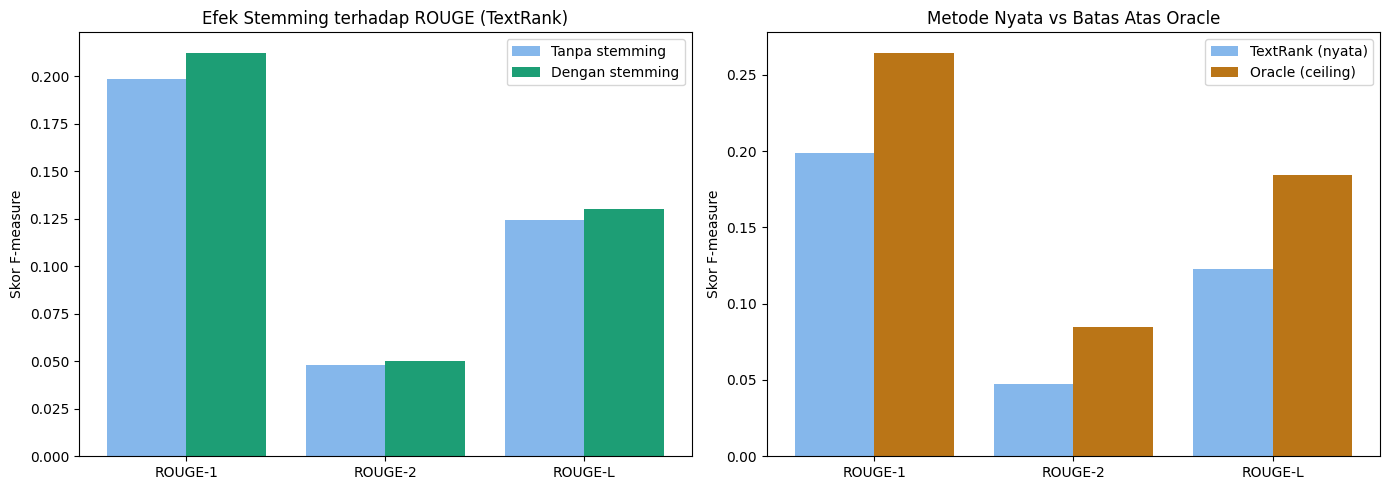

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

labels = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
x = np.arange(len(labels))
ax[0].bar(x - 0.2, tanpa, 0.4, label='Tanpa stemming', color='#85B7EB')
ax[0].bar(x + 0.2, dengan, 0.4, label='Dengan stemming', color='#1D9E75')
ax[0].set_xticks(x); ax[0].set_xticklabels(labels)
ax[0].set_title('Efek Stemming terhadap ROUGE (TextRank)')
ax[0].set_ylabel('Skor F-measure'); ax[0].legend()

ax[1].bar(x - 0.2, textrank_smpl, 0.4, label='TextRank (nyata)', color='#85B7EB')
ax[1].bar(x + 0.2, oracle_score, 0.4, label='Oracle (ceiling)', color='#BA7517')
ax[1].set_xticks(x); ax[1].set_xticklabels(labels)
ax[1].set_title('Metode Nyata vs Batas Atas Oracle')
ax[1].set_ylabel('Skor F-measure'); ax[1].legend()

plt.tight_layout(); plt.show()

df.drop(columns=['_pred_stem', '_ref_stem'], inplace=True, errors='ignore')

---
## 6. Evaluasi BERTScore

ROUGE mengukur overlap kata (literal). BERTScore mengukur **kemiripan makna** lewat
embedding, jadi lebih adil untuk ringkasan yang memparafrase. Dipakai sebagai metrik
pelengkap ROUGE.

**Catatan bias:** BERTScore memakai model `bert-base-multilingual-cased` (otomatis via
`lang='id'`), BERBEDA dari model `MiniLM` yang dipakai metode extractive BERT di atas.
Pemisahan ini menghindari keuntungan tidak adil saat menilai ringkasan BERT.

In [22]:
# Install bert-score (jalankan sekali)
!pip install -q bert-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.3 MB/s eta 0:00:00


In [23]:
# ============================================================
# BERTScore — hitung pada sampel untuk ketiga metode extractive
# ============================================================
# BERTScore agak berat (load model + encoding), jadi dihitung pada sampel acak.
# Pakai sampel yang sama (seed=42) agar ketiga metode dibandingkan adil.
from bert_score import score as bertscore

SAMPLE_SIZE_BS = 500
sample_bs = df.sample(n=min(SAMPLE_SIZE_BS, len(df)), random_state=42).reset_index(drop=True)

refs = sample_bs['lead_paragraph'].astype(str).tolist()

def hitung_bertscore(pred_col):
    # cands = ringkasan (kandidat), refs = lead_paragraph (ground truth).
    # lang='id' otomatis memilih model multilingual (bukan MiniLM extractive).
    cands = sample_bs[pred_col].astype(str).tolist()
    P, R, F1 = bertscore(cands, refs, lang='id', verbose=False)
    return P.mean().item(), R.mean().item(), F1.mean().item()

print(f'Menghitung BERTScore pada {len(sample_bs)} artikel sampel...\n')

methods_bs = [
    ('TF-IDF',   'summary_tfidf'),
    ('TextRank', 'summary_textrank'),
    ('BERT',     'summary_bert'),
]

print(f'{"Metode":<10} | {"Precision":>9} | {"Recall":>9} | {"F1":>9}')
print('-' * 48)
hasil_bertscore = {}
for name, col in methods_bs:
    p, r, f1 = hitung_bertscore(col)
    hasil_bertscore[name] = (p, r, f1)
    print(f'{name:<10} | {p:>9.4f} | {r:>9.4f} | {f1:>9.4f}')

Menghitung BERTScore pada 500 artikel sampel...

Metode     | Precision |    Recall |        F1
------------------------------------------------


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TextRank   |    0.6580 |    0.6325 |    0.6443


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT       |    0.6603 |    0.6323 |    0.6454


In [24]:
# Perbandingan: peringkat ROUGE vs peringkat BERTScore
# Apakah metode terbaik menurut ROUGE sama dengan menurut BERTScore?
print('Perbandingan F1 (BERTScore) vs ROUGE-L (sudah dihitung sebelumnya):')
print('=' * 55)
print(f'{"Metode":<10} | {"BERTScore-F1":>12} | {"ROUGE-L":>9}')
print('-' * 40)
for name, col in methods_bs:
    bs_f1 = hasil_bertscore[name][2]
    rouge_l = hasil_rouge[name][2]   # dari Skenario 4 / evaluasi ROUGE
    print(f'{name:<10} | {bs_f1:>12.4f} | {rouge_l:>9.4f}')

best_bs = max(hasil_bertscore, key=lambda k: hasil_bertscore[k][2])
best_rouge = max(hasil_rouge, key=lambda k: hasil_rouge[k][2])
print(f'\nTerbaik menurut BERTScore : {best_bs}')
print(f'Terbaik menurut ROUGE-L   : {best_rouge}')
if best_bs != best_rouge:
    print('\n[!] Peringkat BERBEDA antara dua metrik — temuan menarik untuk laporan:')
    print('    metrik berbasis makna vs berbasis kata bisa memberi kesimpulan berbeda.')
else:
    print('\nKedua metrik sepakat pada metode terbaik — hasil konsisten.')

Perbandingan F1 (BERTScore) vs ROUGE-L (sudah dihitung sebelumnya):
Metode     | BERTScore-F1 |   ROUGE-L
----------------------------------------
TF-IDF     |       0.6399 |    0.1198
TextRank   |       0.6443 |    0.1245
BERT       |       0.6454 |    0.1186

Terbaik menurut BERTScore : BERT
Terbaik menurut ROUGE-L   : TextRank

[!] Peringkat BERBEDA antara dua metrik — temuan menarik untuk laporan:
    metrik berbasis makna vs berbasis kata bisa memberi kesimpulan berbeda.
